In [22]:
import sys
import os
import numpy as np

sys.path.append(os.path.abspath('..'))

from src.config import SolverConfig
from src.models.spacecraft import Spacecraft
from src.optimizer import Optimizer
from src.utils import cart2eq, cart2kep

from scripts.ephemerides import load_states

earth_path = "../src/horizons_results_earth_heliocentric_state_vector.txt"
mars_path = "../src/horizons_results_mars_heliocentric_state_vector.txt"

In [23]:
earth_loc, earth_dt = load_states(earth_path)
mars_loc, mars_dt = load_states(mars_path)

earth_loc = earth_loc*1e3
mars_loc = mars_loc*1e3

cfg = SolverConfig()

In [ ]:
t0 = 0

# outer loooooop

departures = np.linspace(0,1,1, dtype=int)
tf_days = np.linspace(600,601,1, dtype=int)

best_tf = None
best_cost = 1e99
best_sol = None

for t0 in departures:
    print("testing departure", t0)
    for tf in tf_days:
        print("testing transfer time", tf)
        Psyche = Spacecraft()
        m0 = Psyche.m0
        r0v0 = earth_loc[t0]
        y0 = np.hstack((r0v0, m0))
        rfvf = mars_loc[t0+tf]
        yf = np.hstack((rfvf, m0))
        print(np.linalg.norm(r0v0))
        print(rfvf)

        fw_target = cart2eq(rfvf)[0:5]
        fw_opt = Optimizer(cfg, Psyche, target_orbit=fw_target)
        fw_ts, fw_sol, fw_as, fw_es = fw_opt.simulate_forward(t0*86400, tf*86400, y0)

        # bw_target = cart2eq(r0v0)[0:5]
        # bw_opt = Optimizer(cfg, Psyche, target_orbit=bw_target)
        # bw_ts, bw_sol, bw_as, bw_es = bw_opt.simulate_backward(tf*86400, t0*86400, yf)

    




testing departure 0
testing transfer time 600
147104360214.35986
[ 1.17918360e+11 -1.72818667e+11 -6.51784742e+09  2.09364785e+04
  1.57311576e+04 -1.85027751e+02]
testing departure 222
testing transfer time 600
151637978835.10687
[ 5.33691630e+10  2.23592547e+11  3.37184956e+09 -2.26454284e+04
  7.68114902e+03  7.17398347e+02]
testing departure 444
testing transfer time 600
148981016282.80084
[-2.47177674e+11  8.60863446e+09  6.25336663e+09  6.33282295e+01
 -2.21442596e+04 -4.65468002e+02]
testing departure 666
testing transfer time 600
148637446655.10986
[ 7.73728459e+10 -1.97110032e+11 -6.03034095e+09  2.34738731e+04
  1.09363407e+04 -3.47608257e+02]
testing departure 888
testing transfer time 600
151817679483.64188
[ 9.31472711e+10  2.05672472e+11  2.02090748e+09 -2.11490240e+04
  1.20590597e+04  7.72241963e+02]
testing departure 1111
testing transfer time 600
147150012966.5011
[-2.44092292e+11  4.65125733e+10  6.97111348e+09 -3.62844386e+03
 -2.17315940e+04 -3.66200824e+02]
testin

In [26]:
# print(r0v0)
# print(rfvf)

# print(fw_sol)
print(np.array(cart2kep(rfvf)[0:5]))
print(np.array(cart2kep(r0v0)[0:5]))

[ 2.27966968e+11  9.33836478e-02  3.22731230e-02  8.64597479e-01
 -1.28286260e+00]
[ 1.49473565e+11  1.75293865e-02  1.55019352e-05 -2.87639688e+00
 -1.61556091e+00]


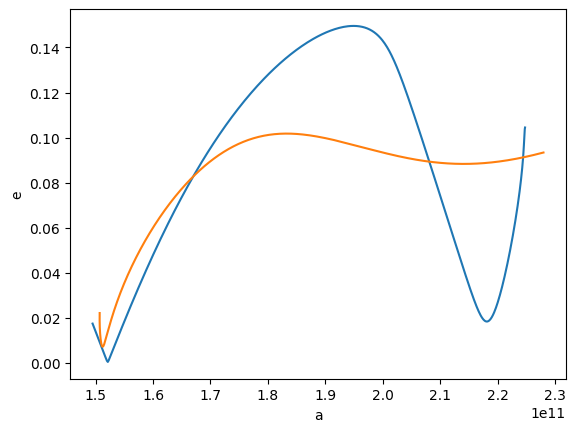

In [27]:
import matplotlib.pyplot as plt

# plt.figure()
# plt.plot(fw_as, label="earthtomars")
# plt.plot(bw_as, label="marstoearth")
# plt.show()

# plt.figure()
# plt.plot(fw_es, label="earthtomars")
# plt.plot(bw_es, label="marstoearth")
# plt.show()

plt.figure()
plt.plot(fw_as, fw_es)
plt.plot(bw_as, bw_es)
plt.xlabel("a")
plt.ylabel("e")
plt.show()

In [28]:
import plotly.graph_objects as go
import numpy as np


# Convert to Gm (1e9 m)
AU_TO_GM = 1.495978707e2

# Example: pick one TOF from your loop
best_tf = tf_days[-1]  # or pick the one you want to visualize
best_t0 = t0

# Get Earth and Mars positions at t0 and t0+best_tf
earth_initial = earth_loc[best_t0,0:3]
mars_initial = mars_loc[best_t0,0:3]
mars_final= mars_loc[best_t0 + best_tf, 0:3]
earth_final= earth_loc[best_t0 + best_tf, 0:3]

# Forward trajectory (Earth -> Mars)
t_days_fw = fw_ts / 86400
r_traj_fw = fw_sol[0:3, :].T / 1e9

# Backward trajectory (Mars -> Earth)
t_days_bw = bw_ts / 86400
r_traj_bw = bw_sol[0:3, :].T / 1e9


# Create 3D figure
fig = go.Figure()


# 1. Forward arc (Earth → Mars)
fig.add_trace(go.Scatter3d(
    x=r_traj_fw[:, 0], y=r_traj_fw[:, 1], z=r_traj_fw[:, 2],
    mode='lines',
    name='Forward Q‑law arc (Earth → Mars)',
    line=dict(width=6, color='cyan'),
    hovertemplate='<b>Time: %{text:.1f} days</b><br>X: %{x:.2f} Gm<br>Y: %{y:.2f} Gm<br>Z: %{z:.2f} Gm<extra></extra>',
    text=t_days_fw
))


# 2. Backward arc (Mars → Earth)
fig.add_trace(go.Scatter3d(
    x=r_traj_bw[:, 0], y=r_traj_bw[:, 1], z=r_traj_bw[:, 2],
    mode='lines',
    name='Backward Q‑law arc (Mars → Earth)',
    line=dict(width=6, color='orange'),
    hovertemplate='<b>Time: %{text:.1f} days</b><br>X: %{x:.2f} Gm<br>Y: %{y:.2f} Gm<br>Z: %{z:.2f} Gm<extra></extra>',
    text=t_days_bw
))


# 3. Earth initial
fig.add_trace(go.Scatter3d(
    x=[earth_initial[0]/1e9], y=[earth_initial[1]/1e9], z=[earth_initial[2]/1e9],
    mode='markers+text',
    name='Earth (Start)',
    marker=dict(size=12, color='blue'),
    text=['Earth Start'],
    textposition="middle center",
    hovertemplate='<b>Earth Initial</b><br>Position: (%{x:.2f}, %{y:.2f}, %{z:.2f}) Gm<extra></extra>'
))


# 4. Mars initial
fig.add_trace(go.Scatter3d(
    x=[mars_initial[0]/1e9], y=[mars_initial[1]/1e9], z=[mars_initial[2]/1e9],
    mode='markers+text',
    name='Mars (Start)',
    marker=dict(size=12, color='pink'),
    text=['Mars Start'],
    textposition="middle center",
    hovertemplate='<b>Mars Initial</b><br>Position: (%{x:.2f}, %{y:.2f}, %{z:.2f}) Gm<extra></extra>'
))


# 5. Mars final (target)
fig.add_trace(go.Scatter3d(
    x=[mars_final[0]/1e9], y=[mars_final[1]/1e9], z=[mars_final[2]/1e9],
    mode='markers+text',
    name='Mars (Target)',
    marker=dict(size=12, color='red'),
    text=['Mars Target'],
    textposition="middle center",
    hovertemplate='<b>Mars Target</b><br>Position: (%{x:.2f}, %{y:.2f}, %{z:.2f}) Gm<extra></extra>'
))


# 6. Earth final (target for backward arc)
fig.add_trace(go.Scatter3d(
    x=[earth_final[0]/1e9], y=[earth_final[1]/1e9], z=[earth_final[2]/1e9],
    mode='markers+text',
    name='Earth (Target)',
    marker=dict(size=12, color='lightblue'),
    text=['Earth Target'],
    textposition="middle center",
    hovertemplate='<b>Earth Target</b><br>Position: (%{x:.2f}, %{y:.2f}, %{z:.2f}) Gm<extra></extra>'
))


# 7. Sun at origin
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    name='Sun',
    marker=dict(size=15, color='yellow', symbol='circle', line=dict(color='orange', width=2))
))


# 8. Auxiliary: Earth initial state point (r0v0) and Mars final state point 

In [ ]:
mars_r, mars_v = mars_state(best_tf)
print("Final spacecraft z:", sol[2, -1])
print("Mars z:", mars_r[2])
print("Final spacecraft vz:", sol[5, -1])
print("Mars vz:", mars_v[2])

print("final osculating", np.array(cart2eq(sol[0:6,-1])))
print("final orbital error", np.array(cart2eq(sol[0:6,-1]))- np.array(cart2eq(np.hstack([mars_r, mars_v]))))

NameError: name 'mars_state' is not defined

In [ ]:
print(best_ts[-10:-1]/86400)

In [ ]:
# Jupyter Notebook Cell - Plot Best Trajectory
import plotly.graph_objects as go
import numpy as np
import json

# Get planet states
earth_initial, earth_initial_v = earth_state(best_t0)
mars_initial, _ = mars_state(best_t0)
mars_final, mars_final_v = mars_state(best_tf)
earth_final, earth_final_v = earth_state(best_tf)

# Extract trajectory data
t_days = best_ts / 86400  # Convert to days
r_traj = best_sol[0:3, :].T / 1e9  # Position in Gm (Gigameters)
Sun_pos = np.zeros((len(t_days), 3))

# Create 3D trajectory plot
fig = go.Figure()

# 1. Spacecraft trajectory
fig.add_trace(go.Scatter3d(
    x=r_traj[:, 0], y=r_traj[:, 1], z=r_traj[:, 2],
    mode='lines',
    name='Spacecraft Trajectory',
    line=dict(width=5, color='cyan'),
    hovertemplate='<b>Time: %{text:.1f} days</b><br>X: %{x:.2f} Gm<br>Y: %{y:.2f} Gm<br>Z: %{z:.2f} Gm<extra></extra>',
    text=t_days
))

# 2. Earth initial position
fig.add_trace(go.Scatter3d(
    x=[earth_initial[0]/1e9], y=[earth_initial[1]/1e9], z=[earth_initial[2]/1e9],
    mode='markers+text',
    name='Earth (Start)',
    marker=dict(size=12, color='blue'),
    text=['Earth Start'],
    textposition="middle center",
    hovertemplate='<b>Earth Initial</b><br>Position: (%{x:.2f}, %{y:.2f}, %{z:.2f}) Gm<extra></extra>'
))

# 2. Mars initial position
fig.add_trace(go.Scatter3d(
    x=[mars_initial[0]/1e9], y=[mars_initial[1]/1e9], z=[mars_initial[2]/1e9],
    mode='markers+text',
    name='Mars (Start)',
    marker=dict(size=12, color='pink'),
    text=['Mars Start'],
    textposition="middle center",
    hovertemplate='<b>Mars Initial</b><br>Position: (%{x:.2f}, %{y:.2f}, %{z:.2f}) Gm<extra></extra>'
))

# 3. Mars final position  
fig.add_trace(go.Scatter3d(
    x=[mars_final[0]/1e9], y=[mars_final[1]/1e9], z=[mars_final[2]/1e9],
    mode='markers+text',
    name='Mars (Target)',
    marker=dict(size=12, color='red'),
    text=['Mars Target'],
    textposition="middle center",
    hovertemplate='<b>Mars Target</b><br>Position: (%{x:.2f}, %{y:.2f}, %{z:.2f}) Gm<extra></extra>'
))

# 3. Mars final position  
fig.add_trace(go.Scatter3d(
    x=[earth_final[0]/1e9], y=[earth_final[1]/1e9], z=[earth_final[2]/1e9],
    mode='markers+text',
    name='Earth (Final)',
    marker=dict(size=12, color='lightblue'),
    text=['Earth Final'],
    textposition="middle center",
    hovertemplate='<b>earth final</b><br>Position: (%{x:.2f}, %{y:.2f}, %{z:.2f}) Gm<extra></extra>'
))

# 4. Sun at origin
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    name='Sun',
    marker=dict(size=15, color='yellow', symbol='circle', line=dict(color='orange', width=2))
))

# singularity = np.array([np.float64(304716607855.87244), np.float64(0.41952194992930414), np.float64(0.0933371625352002), np.float64(0.012720020031905307), np.float64(0.006673122262868969), np.float64(0.4760303596677451)])
# singularity_cart = eq2cart(singularity)
# fig.add_trace(go.Scatter3d(
#     x=[singularity_cart[0]], y=[singularity_cart[1]], z=[singularity_cart[2]],
#     mode='markers',
#     name='singularity?',
#     marker=dict(size=15, color='black', symbol='circle', line=dict(color='orange', width=2))
# ))

# Layout
fig.update_layout(
    title=dict(
        text="Earth-Mars Low-Thrust Transfer Trajectory<br><sup>TOF: {:.1f} days | Final Distance Error: {:.1f} Mm</sup>".format(
            best_tf/86400, np.linalg.norm(best_sol[0:3,-1] - mars_final)
        ),
        x=0.05,
        xanchor='left'
    ),
    scene=dict(
        xaxis_title="X (Gm)",
        yaxis_title="Y (Gm)", 
        zaxis_title="Z (Gm)",
        aspectmode='cube',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.0))
    ),
    showlegend=True,
    height=700,
    hovermode='closest'
)

# Show interactive plot in Jupyter
fig.show()

# Print key stats
print(f"🚀 Mission Summary:")
print(f"   Duration: {best_tf/86400:.1f} days")
print(f"   Final pos error: {np.linalg.norm(best_sol[0:3,-1] - mars_final)/1e6:.1f} Mm")
print(f"   Final vel error: {np.linalg.norm(best_sol[3:6,-1] - mars_final_v)/1e3:.1f} km/s")
print(f"   Final mass: {best_sol[6,-1]:.0f} kg")
print(f"   Delta-V used: {(m0 - best_sol[6,-1])/m0*100:.1f}% of initial mass")

In [ ]:
print(sol[0:3,-1])